# Exploratory Data Analysis (EDA)

## Objective:
Develop machine learning (ML) models to find solutions in optimising crop yields and resource management that stems from inefficiencies in our controlled environment farming systems. Before we move onto developing ML models, we will first conduct explorartory data analysis (EDA). The EDA steps are as follows below.

### Steps in EDA:
1. Data Cleaning
2. Univariate Analysis
3. Multivariate Analysis
4. Feature Engineering
5. Insights and Recommendations


## Dataset Overview:

The data source comes from agri.db where the following attributes and description can be found below:

| **Attribute**                 | **Description**                                                                 |
|-------------------------------|---------------------------------------------------------------------------------|
| **System Location Code**      | Code representing the specific zone or area within the farm.                   |
| **Previous Cycle Plant Type** | Type of plant grown in the previous cycle in the same location.                |
| **Plant Type**                | Current type of plant being grown.                                             |
| **Plant Stage**               | Current growth stage of the plant (e.g., seedling, vegetative, maturity).      |
| **Temperature Sensor (°C)**   | Temperature reading from the sensor, measured in degrees Celsius.              |
| **Humidity Sensor (%)**       | Humidity level as measured by the sensor, in percentage.                       |
| **Light Intensity Sensor (lux)** | Light intensity measured by the sensor, in lux.                                |
| **CO2 Sensor (ppm)**          | Carbon dioxide concentration measured by the sensor, in parts per million.     |
| **EC Sensor (dS/m)**          | Electrical conductivity measured by the sensor, in decisiemens per meter.      |
| **O2 Sensor (ppm)**           | Oxygen concentration measured by the sensor, in parts per million.             |
| **Nutrient N Sensor (ppm)**   | Nitrogen concentration measured by the sensor, in parts per million.           |
| **Nutrient P Sensor (ppm)**   | Phosphorus concentration measured by the sensor, in parts per million.         |
| **Nutrient K Sensor (ppm)**   | Potassium concentration measured by the sensor, in parts per million.          |
| **pH Sensor**                 | pH level measured by the sensor.                                               |
| **Water Level Sensor (mm)**   | Water level measurement by the sensor, in millimeters.                         |

---
### **Assumptions About the Dataset:**
To ensure clarity and context for analysis, the following assumptions were made about the data source:
- Synthetic data accurately mimics real-world conditions in terms of distributions and variability.
- Observations are independent unless specified otherwise.
- Sensor readings are assumed to be free of calibration errors.
- Any missing data is random and has been imputed appropriately.


In [2]:

# Install packages required

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
"""

Using query_database to query the agri.db database and list_tables to show the available tables found in agri_db. 
With the table name, we can use sql query to call the correct table.

"""

# Path to the database
db_path = "C:/Users/Razer/.vscode/aiap19-Nathan-Lim-Long-Jun-816H/Data/agri.db"
# Function to query the database
def query_database(db_path, query):
    conn = sqlite3.connect(db_path)
    agri_data = pd.read_sql_query(query, conn)
    conn.close()
    return agri_data

# Example: List all tables in the database
def list_tables(db_path):
    conn = sqlite3.connect(db_path)
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables = pd.read_sql_query(query, conn)
    conn.close()
    return tables

tables = list_tables(db_path)
print("Available tables:", tables)


Available tables:         name
0  farm_data


## Data Query from agri.db

In [4]:
# Query farm_table
query = "SELECT * FROM farm_data;"
agri_data = query_database(db_path, query)

# Print the first 10 rows
if not agri_data.empty:
    print(agri_data.head(10))
else:
    print("No data found in the table 'farm_data'.")


  System Location Code Previous Cycle Plant Type           Plant Type  \
0               Zone_D                     Herbs           Vine Crops   
1               Zone_G                     Herbs           VINE CROPS   
2               Zone_F                     Herbs                herbs   
3               Zone_G                     Herbs  fruiting vegetables   
4               Zone_B                Vine Crops         LEAFY GREENS   
5               Zone_C                Vine Crops  FRUITING VEGETABLES   
6               Zone_A              Leafy Greens           Vine Crops   
7               Zone_G                     Herbs         Leafy Greens   
8               Zone_G                     Herbs         Leafy Greens   
9               Zone_B                Vine Crops           Vine Crops   

  Plant Stage  Temperature Sensor (°C)  Humidity Sensor (%)  \
0    Maturity                    23.34                  NaN   
1  Vegetative                   -24.16                63.14   
2    ma

## 1. Data Cleaning

Objective: Ensuring data hygiene

In [5]:

# .shape to find out structure of df (how many rows and columns)
print(agri_data.shape)



(57489, 15)


## Checking for empty or NULL values in the agri.db dataset

In [6]:
# Checking for empty or NULL values in the dataset

print(agri_data.isnull())  # Returns a DataFrame with True for missing values
print("\nMissing values count per column:")
print(agri_data.isnull().sum())  # Summarizes missing values per column

print("\nPercentage of missing values per column:")
print(agri_data.isnull().mean() * 100)

       System Location Code  Previous Cycle Plant Type  Plant Type  \
0                     False                      False       False   
1                     False                      False       False   
2                     False                      False       False   
3                     False                      False       False   
4                     False                      False       False   
...                     ...                        ...         ...   
57484                 False                      False       False   
57485                 False                      False       False   
57486                 False                      False       False   
57487                 False                      False       False   
57488                 False                      False       False   

       Plant Stage  Temperature Sensor (°C)  Humidity Sensor (%)  \
0            False                    False                 True   
1            False     

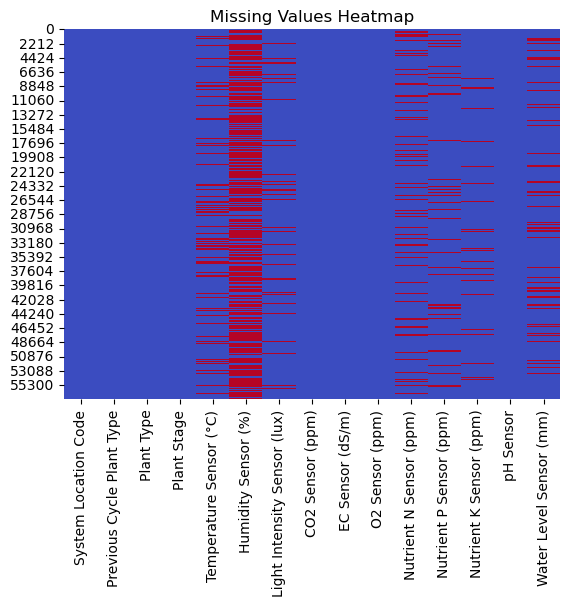

In [7]:
# Heatmap showing missing values across the different rows in agri_data

sns.heatmap(agri_data.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()


### Findings:

#### **Columns with High Missing Values**
- **Humidity Sensor (%)**: 67.6% missing.

#### **Columns with Moderate Missing Values**
- **Nutrient N Sensor (ppm)**: 17.3% missing.  
- **Temperature Sensor (°C)**: ~15% missing.  
- **Water Level Sensor (mm)**: ~15% missing.  
- **Light Intensity Sensor (lux)**: 7.4% missing.  
- **Nutrient P Sensor (ppm)**: 9.9% missing.  
- **Nutrient K Sensor (ppm)**: 6.4% missing.  

#### **Columns with No Missing Values**
- **System Location Code**  
- **Previous Cycle Plant Type**  
- **Plant Type**  
- **Plant Stage**  
- **CO2 Sensor (ppm)**  
- **EC Sensor (dS/m)**  
- **O2 Sensor (ppm)**  
- **pH Sensor**  

---

### Next Steps:

#### **1. Drop "Humidity Sensor (%)"**
- **Reasoning**:  
  - This column has a significant amount of missing data (67.6%), making it impractical to retain without introducing significant bias or noise.  
  - Humidity is not identified as a critical predictor based on initial analysis, and its removal avoids unnecessary complexity in the modeling process.  
  - Dropping the column ensures the dataset remains clean and focused on more reliable and relevant features.  


#### **2. Impute Missing Values for Moderately Missing Columns**
- **Affected Columns**:  
  - **Nutrient N Sensor (ppm)**: 17.3% missing.  
  - **Temperature Sensor (°C)**: ~15% missing.  
  - **Water Level Sensor (mm)**: ~15% missing.  
  - **Light Intensity Sensor (lux)**: 7.4% missing.  
  - **Nutrient P Sensor (ppm)**: 9.9% missing.  
  - **Nutrient K Sensor (ppm)**: 6.4% missing.  

- **Proposed Solution**: Replace missing values with the **median** of the respective columns.  

- **Justification**:  
  - **Median Imputation**:  
    - The median is a robust measure of central tendency that is less influenced by outliers compared to the mean.  
    - Imputing with the median ensures that the imputed values are representative of the overall data distribution.  
  - **Manageable Missingness**:  
    - These columns have moderate levels of missing values (<20%), making imputation a more effective solution than dropping them entirely, which could lead to a loss of valuable information.  
  - **Relevance to Predictions**:  
    - These features likely hold significant information for predictive modeling, particularly for understanding plant growth dynamics and environmental conditions. Retaining and imputing them enhances model accuracy and interpretability.  

---

## Checking data types of features in table

Checking data types to understand what kind of data we are dealing with and decide what kind of predictive models we may employ in the subsequent steps.

In [8]:
# Check the data types of all columns
print(agri_data.dtypes)

System Location Code             object
Previous Cycle Plant Type        object
Plant Type                       object
Plant Stage                      object
Temperature Sensor (°C)         float64
Humidity Sensor (%)             float64
Light Intensity Sensor (lux)    float64
CO2 Sensor (ppm)                  int64
EC Sensor (dS/m)                float64
O2 Sensor (ppm)                   int64
Nutrient N Sensor (ppm)          object
Nutrient P Sensor (ppm)          object
Nutrient K Sensor (ppm)          object
pH Sensor                       float64
Water Level Sensor (mm)         float64
dtype: object


Expected Nutrient N/P/K Sensor readings to be integers but they are object type. We will employ .to_numeric to change column from object to numeric data type.

In [9]:
# Seems that Nutrient N/P/K Sensor are objects even though in reality it is supposed to be integers.

# Convert the column to numeric, coercing non-numeric values to NaN
agri_data['Nutrient N Sensor (ppm)'] = pd.to_numeric(agri_data['Nutrient N Sensor (ppm)'], errors='coerce')
agri_data['Nutrient P Sensor (ppm)'] = pd.to_numeric(agri_data['Nutrient P Sensor (ppm)'], errors='coerce')
agri_data['Nutrient K Sensor (ppm)'] = pd.to_numeric(agri_data['Nutrient K Sensor (ppm)'], errors='coerce')

# Check data type again
# Check the data types of all columns
print(agri_data.dtypes)


System Location Code             object
Previous Cycle Plant Type        object
Plant Type                       object
Plant Stage                      object
Temperature Sensor (°C)         float64
Humidity Sensor (%)             float64
Light Intensity Sensor (lux)    float64
CO2 Sensor (ppm)                  int64
EC Sensor (dS/m)                float64
O2 Sensor (ppm)                   int64
Nutrient N Sensor (ppm)         float64
Nutrient P Sensor (ppm)         float64
Nutrient K Sensor (ppm)         float64
pH Sensor                       float64
Water Level Sensor (mm)         float64
dtype: object


Mentioned earlier to do the following:

1) Drop "Humidity Sensor (%)" since it has a large number of missing values
2) Use column median value to fill in the empty rows for Nutrient N Sensor (ppm), Temperature Sensor (°C), Water Level Sensor (mm), Light Intensity Sensor (lux), Nutrient P Sensor (ppm) & Nutrient K Sensor (ppm).

In [10]:
# Data Handling for missing data

# Drop column with high % of missing values
agri_data_cleaned = agri_data.drop(columns=['Humidity Sensor (%)'])

# Impute missing values with mean for columns with moderate levels of missing values
agri_data_cleaned['Temperature Sensor (°C)'] = agri_data_cleaned['Temperature Sensor (°C)'].fillna(agri_data_cleaned['Temperature Sensor (°C)'].mean())
agri_data_cleaned['Water Level Sensor (mm)'] = agri_data_cleaned['Water Level Sensor (mm)'].fillna(agri_data_cleaned['Water Level Sensor (mm)'].mean())
agri_data_cleaned['Nutrient N Sensor (ppm)'] = agri_data_cleaned['Nutrient N Sensor (ppm)'].fillna(agri_data_cleaned['Nutrient N Sensor (ppm)'].mean())
agri_data_cleaned['Light Intensity Sensor (lux)'] = agri_data_cleaned['Light Intensity Sensor (lux)'].fillna(agri_data_cleaned['Light Intensity Sensor (lux)'].mean())
agri_data_cleaned['Nutrient P Sensor (ppm)'] = agri_data_cleaned['Nutrient P Sensor (ppm)'].fillna(agri_data_cleaned['Nutrient P Sensor (ppm)'].mean())
agri_data_cleaned['Nutrient K Sensor (ppm)'] = agri_data_cleaned['Nutrient K Sensor (ppm)'].fillna(agri_data_cleaned['Nutrient K Sensor (ppm)'].mean())

print(agri_data_cleaned.head(10))

  System Location Code Previous Cycle Plant Type           Plant Type  \
0               Zone_D                     Herbs           Vine Crops   
1               Zone_G                     Herbs           VINE CROPS   
2               Zone_F                     Herbs                herbs   
3               Zone_G                     Herbs  fruiting vegetables   
4               Zone_B                Vine Crops         LEAFY GREENS   
5               Zone_C                Vine Crops  FRUITING VEGETABLES   
6               Zone_A              Leafy Greens           Vine Crops   
7               Zone_G                     Herbs         Leafy Greens   
8               Zone_G                     Herbs         Leafy Greens   
9               Zone_B                Vine Crops           Vine Crops   

  Plant Stage  Temperature Sensor (°C)  Light Intensity Sensor (lux)  \
0    Maturity                23.340000                         454.0   
1  Vegetative               -24.160000              

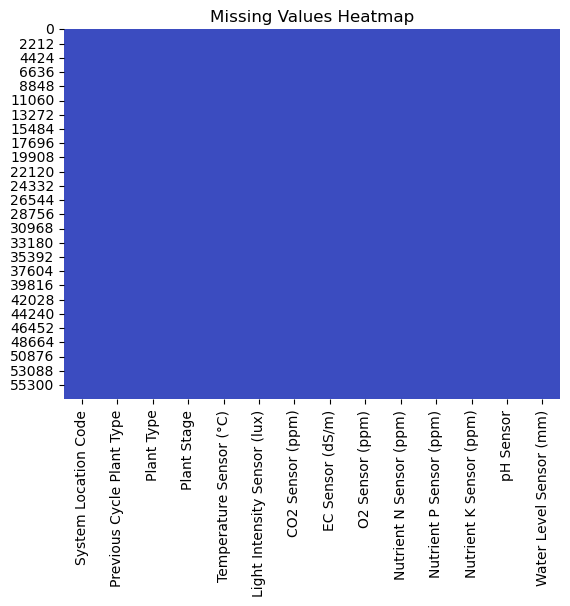

In [11]:
# Rerun heatmap to visualize missing values.

sns.heatmap(agri_data_cleaned.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

On closer inspection of the data set, it seems that object type columns have inconsistent styles.

An example: "Leafy Greens" can be found in multiple forms: 1) LEAFY GREENS 2) leafy greens.

To standardize, we will use title() function make all first letter of every word to be caps.

In [12]:
# Apply capitalization to all object-type columns
for column in agri_data_cleaned.select_dtypes(include=['object']).columns:
    agri_data_cleaned[column] = agri_data_cleaned[column].str.title()

print(agri_data_cleaned.head(10))

  System Location Code Previous Cycle Plant Type           Plant Type  \
0               Zone_D                     Herbs           Vine Crops   
1               Zone_G                     Herbs           Vine Crops   
2               Zone_F                     Herbs                Herbs   
3               Zone_G                     Herbs  Fruiting Vegetables   
4               Zone_B                Vine Crops         Leafy Greens   
5               Zone_C                Vine Crops  Fruiting Vegetables   
6               Zone_A              Leafy Greens           Vine Crops   
7               Zone_G                     Herbs         Leafy Greens   
8               Zone_G                     Herbs         Leafy Greens   
9               Zone_B                Vine Crops           Vine Crops   

  Plant Stage  Temperature Sensor (°C)  Light Intensity Sensor (lux)  \
0    Maturity                23.340000                         454.0   
1  Vegetative               -24.160000              

In [13]:
# Function to get distinct text values for each column
def get_distinct_text_values(df):
    text_values = {}
    for column in df.columns:
        if df[column].dtype == 'object':  # Check for object data type
            text_values[column] = df[column].unique()
        else:
            # Include numeric columns if they contain non-numeric values
            non_numeric = df[column].apply(lambda x: isinstance(x, str))
            if non_numeric.any():
                text_values[column] = df[column][non_numeric].unique()
    return text_values

# Get distinct text values
distinct_text = get_distinct_text_values(agri_data_cleaned)

# Print results
for column, values in distinct_text.items():
    print(f"Column: {column}")
    print(f"Distinct Text Values: {values}")
    print()

Column: System Location Code
Distinct Text Values: ['Zone_D' 'Zone_G' 'Zone_F' 'Zone_B' 'Zone_C' 'Zone_A' 'Zone_E']

Column: Previous Cycle Plant Type
Distinct Text Values: ['Herbs' 'Vine Crops' 'Leafy Greens' 'Fruiting Vegetables']

Column: Plant Type
Distinct Text Values: ['Vine Crops' 'Herbs' 'Fruiting Vegetables' 'Leafy Greens']

Column: Plant Stage
Distinct Text Values: ['Maturity' 'Vegetative' 'Seedling']



After using .title() function to standardize all the object type columns, using .distinct() function to validate, the columns now have clear and distinct categories.

In [14]:
agri_data_cleaned.describe(())

,Temperature Sensor (°C),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
count,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000,57489.000000
mean,22.138201,397.841668,1083.376576,1.624435,6.580842,157.674202,49.859782,217.956227,6.021446,25.716878
std,6.962499,214.469028,172.570351,0.415535,1.145534,41.447805,14.595438,58.557032,0.400251,5.360404
min,-28.570000,-799.000000,799.000000,-0.250000,3.000000,49.000000,19.000000,99.000000,3.800000,10.001955
50%,22.850000,397.841668,1071.000000,1.650000,7.000000,157.674202,49.859782,217.956227,6.000000,25.716878
max,28.750000,800.000000,1500.000000,3.440000,11.000000,250.000000,80.000000,350.000000,7.800000,39.998717


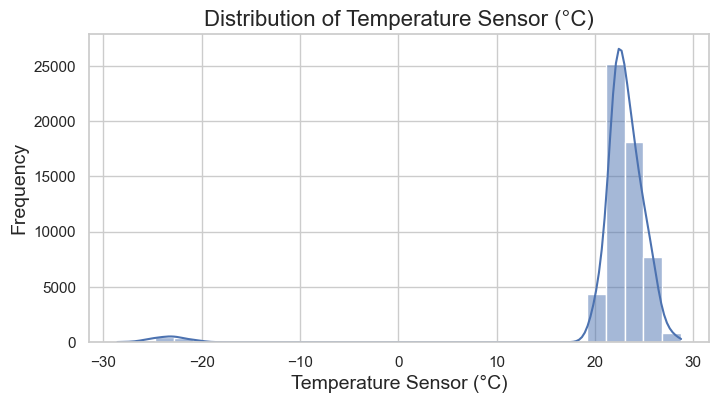

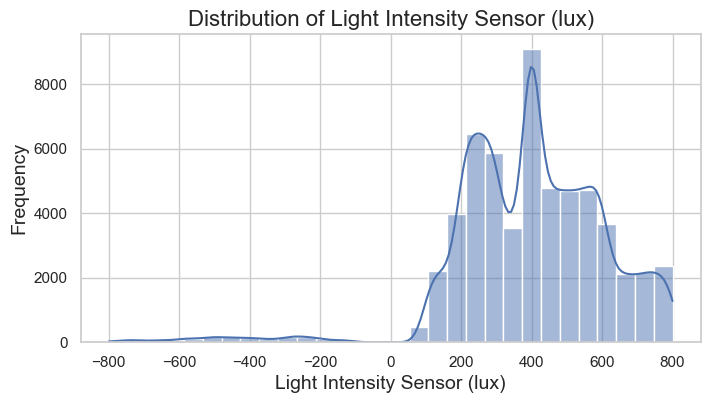

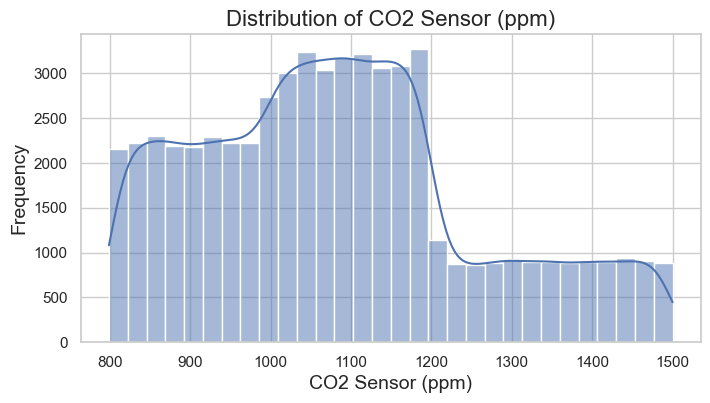

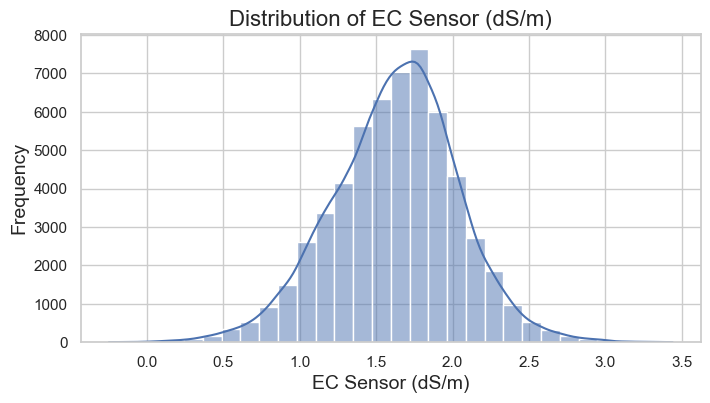

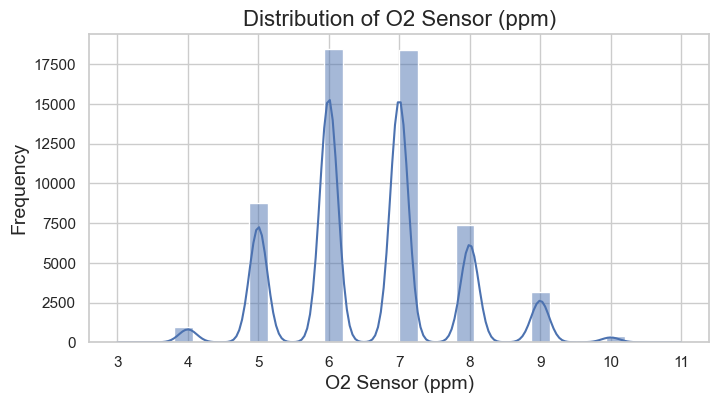

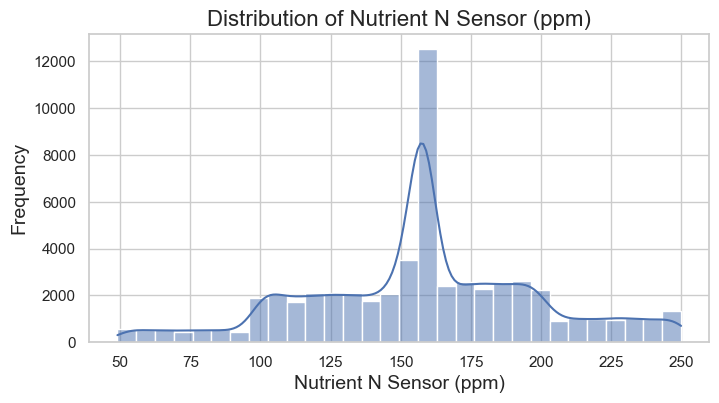

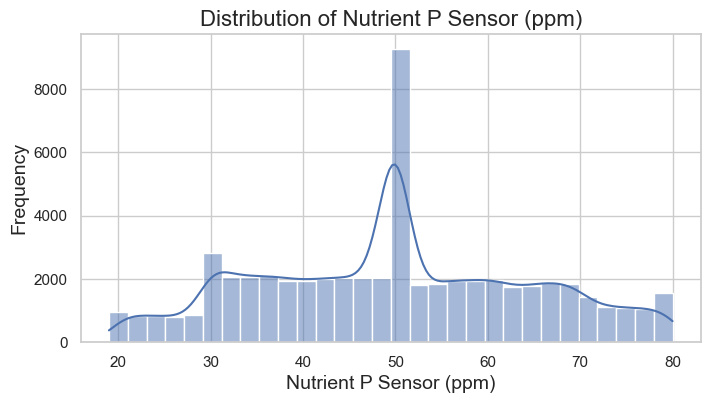

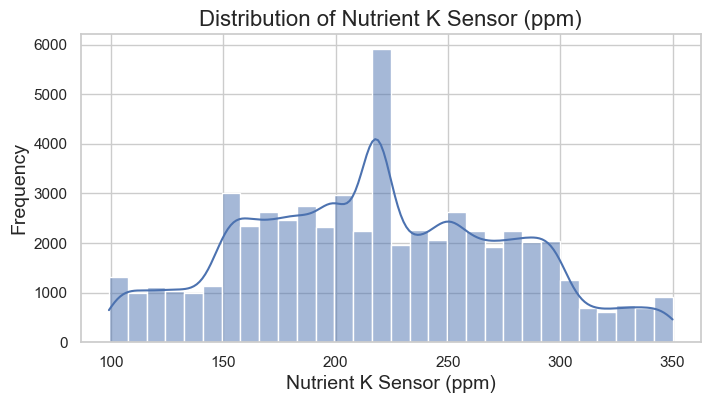

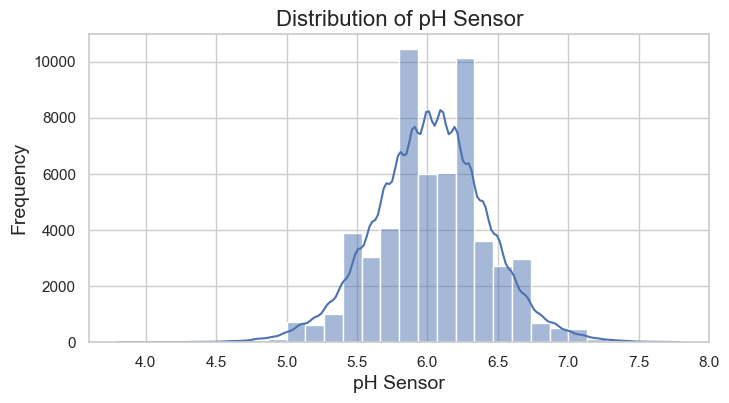

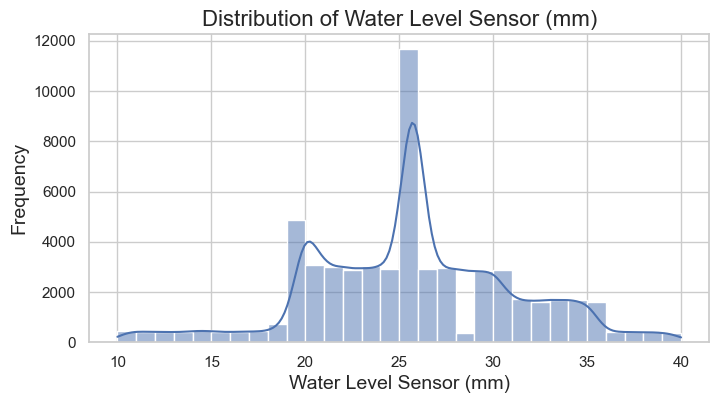

In [15]:

# Select columns whose data types are numeric
numeric_columns = agri_data_cleaned.select_dtypes(include=['number'])

# Set the style of the plots
sns.set(style="whitegrid")

# Create distribution plots for all numeric columns
for column in numeric_columns.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(numeric_columns[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}', fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True)
    plt.show()


In [16]:
# Check how many negative values per column

# Select only numeric columns
numeric_columns = agri_data_cleaned.select_dtypes(include=['number'])

# Calculate % of negative values per column
negative_percentages = (numeric_columns < 0).mean() * 100

print(negative_percentages)



Temperature Sensor (°C)         2.177808
Light Intensity Sensor (lux)    2.409157
CO2 Sensor (ppm)                0.000000
EC Sensor (dS/m)                0.024352
O2 Sensor (ppm)                 0.000000
Nutrient N Sensor (ppm)         0.000000
Nutrient P Sensor (ppm)         0.000000
Nutrient K Sensor (ppm)         0.000000
pH Sensor                       0.000000
Water Level Sensor (mm)         0.000000
dtype: float64


### Findings:

1. **Distribution of Numeric Columns**:  
   - Most numeric columns exhibit normal distributions.  
   - **Exception**: The **CO2 Sensor (ppm)** data is **right-skewed**, indicating potential outliers or an uneven spread in the dataset.  

2. **Negative Values in Sensors**:  
   - **Light Intensity Sensor (lux)** and **EC Sensor (dS/m)** contain **negative values**, which are **abnormal** for these measurements. This suggests **sensor noise** or **faulty equipment** during data collection.  

3. **Unrealistic Temperature Values**:  
   - Although temperatures can occasionally drop below 0°C, the dataset contains values as low as **-20°C**, which is **unusual** for the observed range (20°C to 30°C). These extreme values may indicate **errors in data collection** possibly due to sensor issue.  

---

### Next Steps:

1. **Remove Rows with Negative Values**:  
   - **Reasoning**:  
     - Negative readings for **light intensity**, **EC**, and **temperature** are **not physically plausible** in this context.  
     - Retaining these rows could negatively impact model performance and interpretability.  
   - **Action**:  
     - Filter out rows where numeric columns contain negative values.  
     - This ensures the dataset only includes valid, meaningful observations, improving the quality and reliability of the data for further analysis.  

---

In [17]:
# Filter out negative values

# Select only numeric columns
numeric_columns = agri_data_cleaned.select_dtypes(include=['number'])

# Filter rows where all numeric columns are non-negative
agri_data_cleaned_filtered = agri_data_cleaned[(numeric_columns >= 0).all(axis=1)]

agri_data_cleaned_filtered.describe()


,Temperature Sensor (°C),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
count,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000,54874.000000
mean,23.151391,418.188132,1083.506196,1.625177,6.580931,157.723839,49.866610,217.989640,6.021498,25.714697
std,1.547004,171.848071,172.678382,0.414455,1.145010,41.469782,14.590983,58.584823,0.400712,5.363343
min,18.930000,99.000000,799.000000,0.000000,3.000000,49.000000,19.000000,99.000000,3.800000,10.001955
25%,22.138201,274.000000,950.000000,1.360000,6.000000,132.000000,39.000000,174.000000,5.800000,22.000000
50%,22.900000,397.841668,1072.000000,1.650000,7.000000,157.674202,49.859782,217.956227,6.000000,25.716878
75%,24.090000,544.000000,1178.000000,1.900000,7.000000,183.000000,61.000000,262.000000,6.300000,29.000000
max,28.750000,800.000000,1500.000000,3.440000,11.000000,250.000000,80.000000,350.000000,7.800000,39.998717


## Encoding for Object Type Columns

This is to enable ease of analysis of these columns and included in machine learning models.

In [18]:
'''
Column: System Location Code
Distinct Text Values: ['Zone_D' 'Zone_G' 'Zone_F' 'Zone_B' 'Zone_C' 'Zone_A' 'Zone_E']

Column: Previous Cycle Plant Type
Distinct Text Values: ['Herbs' 'Vine Crops' 'Leafy Greens' 'Fruiting Vegetables']

Column: Plant Type
Distinct Text Values: ['Vine Crops' 'Herbs' 'Fruiting Vegetables' 'Leafy Greens']

Column: Plant Stage
Distinct Text Values: ['Maturity' 'Vegetative' 'Seedling']
'''


# Encoding Plant Stage

# Define a mapping
stage_mapping = {'Seedling': 0, 'Vegetative': 1, 'Maturity': 2}

# Apply mapping
agri_data_cleaned_filtered['Plant Stage Encoded'] = agri_data_cleaned_filtered['Plant Stage'].map(stage_mapping)

print(agri_data_cleaned_filtered[['Plant Stage', 'Plant Stage Encoded']])



      Plant Stage  Plant Stage Encoded
0        Maturity                    2
2        Maturity                    2
3      Vegetative                    1
4        Seedling                    0
5        Maturity                    2
...           ...                  ...
57484    Maturity                    2
57485    Maturity                    2
57486    Seedling                    0
57487  Vegetative                    1
57488    Maturity                    2

[54874 rows x 2 columns]


C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\4077930285.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['Plant Stage Encoded'] = agri_data_cleaned_filtered['Plant Stage'].map(stage_mapping)


In [19]:

# Encoding Plant Type

# Define a mapping
type_mapping = {'Vine Crops': 0, 'Herbs': 1, 'Fruiting Vegetables':2 , 'Leafy Greens':3}

# Apply mapping
agri_data_cleaned_filtered['Plant Type Encoded'] = agri_data_cleaned_filtered['Plant Type'].map(type_mapping)

print(agri_data_cleaned_filtered[['Plant Type', 'Plant Type Encoded']])

                Plant Type  Plant Type Encoded
0               Vine Crops                   0
2                    Herbs                   1
3      Fruiting Vegetables                   2
4             Leafy Greens                   3
5      Fruiting Vegetables                   2
...                    ...                 ...
57484  Fruiting Vegetables                   2
57485  Fruiting Vegetables                   2
57486           Vine Crops                   0
57487           Vine Crops                   0
57488         Leafy Greens                   3

[54874 rows x 2 columns]


C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\1120123051.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['Plant Type Encoded'] = agri_data_cleaned_filtered['Plant Type'].map(type_mapping)


In [20]:
# Encoding Previous Cycle Plant Type

# Apply mapping
agri_data_cleaned_filtered['Prev Plant Type Encoded'] = agri_data_cleaned_filtered['Previous Cycle Plant Type'].map(type_mapping)

print(agri_data_cleaned_filtered[['Previous Cycle Plant Type', 'Prev Plant Type Encoded']])

      Previous Cycle Plant Type  Prev Plant Type Encoded
0                         Herbs                        1
2                         Herbs                        1
3                         Herbs                        1
4                    Vine Crops                        0
5                    Vine Crops                        0
...                         ...                      ...
57484                Vine Crops                        0
57485                Vine Crops                        0
57486                     Herbs                        1
57487       Fruiting Vegetables                        2
57488       Fruiting Vegetables                        2

[54874 rows x 2 columns]


C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\57071936.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['Prev Plant Type Encoded'] = agri_data_cleaned_filtered['Previous Cycle Plant Type'].map(type_mapping)


In [21]:
# Encoding Zone Type

# Define a mapping
zone_mapping = {'Zone_D': 0, 'Zone_G': 1, 'Zone_F': 2, 'Zone_B': 3, 'Zone_C': 4, 'Zone_A': 5, 'Zone_E': 6}

# Apply mapping
agri_data_cleaned_filtered['System Location Code Encoded'] = agri_data_cleaned_filtered['System Location Code'].map(zone_mapping)

print(agri_data_cleaned_filtered[['System Location Code', 'System Location Code Encoded']])

      System Location Code  System Location Code Encoded
0                   Zone_D                             0
2                   Zone_F                             2
3                   Zone_G                             1
4                   Zone_B                             3
5                   Zone_C                             4
...                    ...                           ...
57484               Zone_C                             4
57485               Zone_C                             4
57486               Zone_E                             6
57487               Zone_G                             1
57488               Zone_F                             2

[54874 rows x 2 columns]


C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\2716978893.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['System Location Code Encoded'] = agri_data_cleaned_filtered['System Location Code'].map(zone_mapping)


## 2) Univariate Analysis:
Distribution of all columns found in agri_data_cleaned_filtered

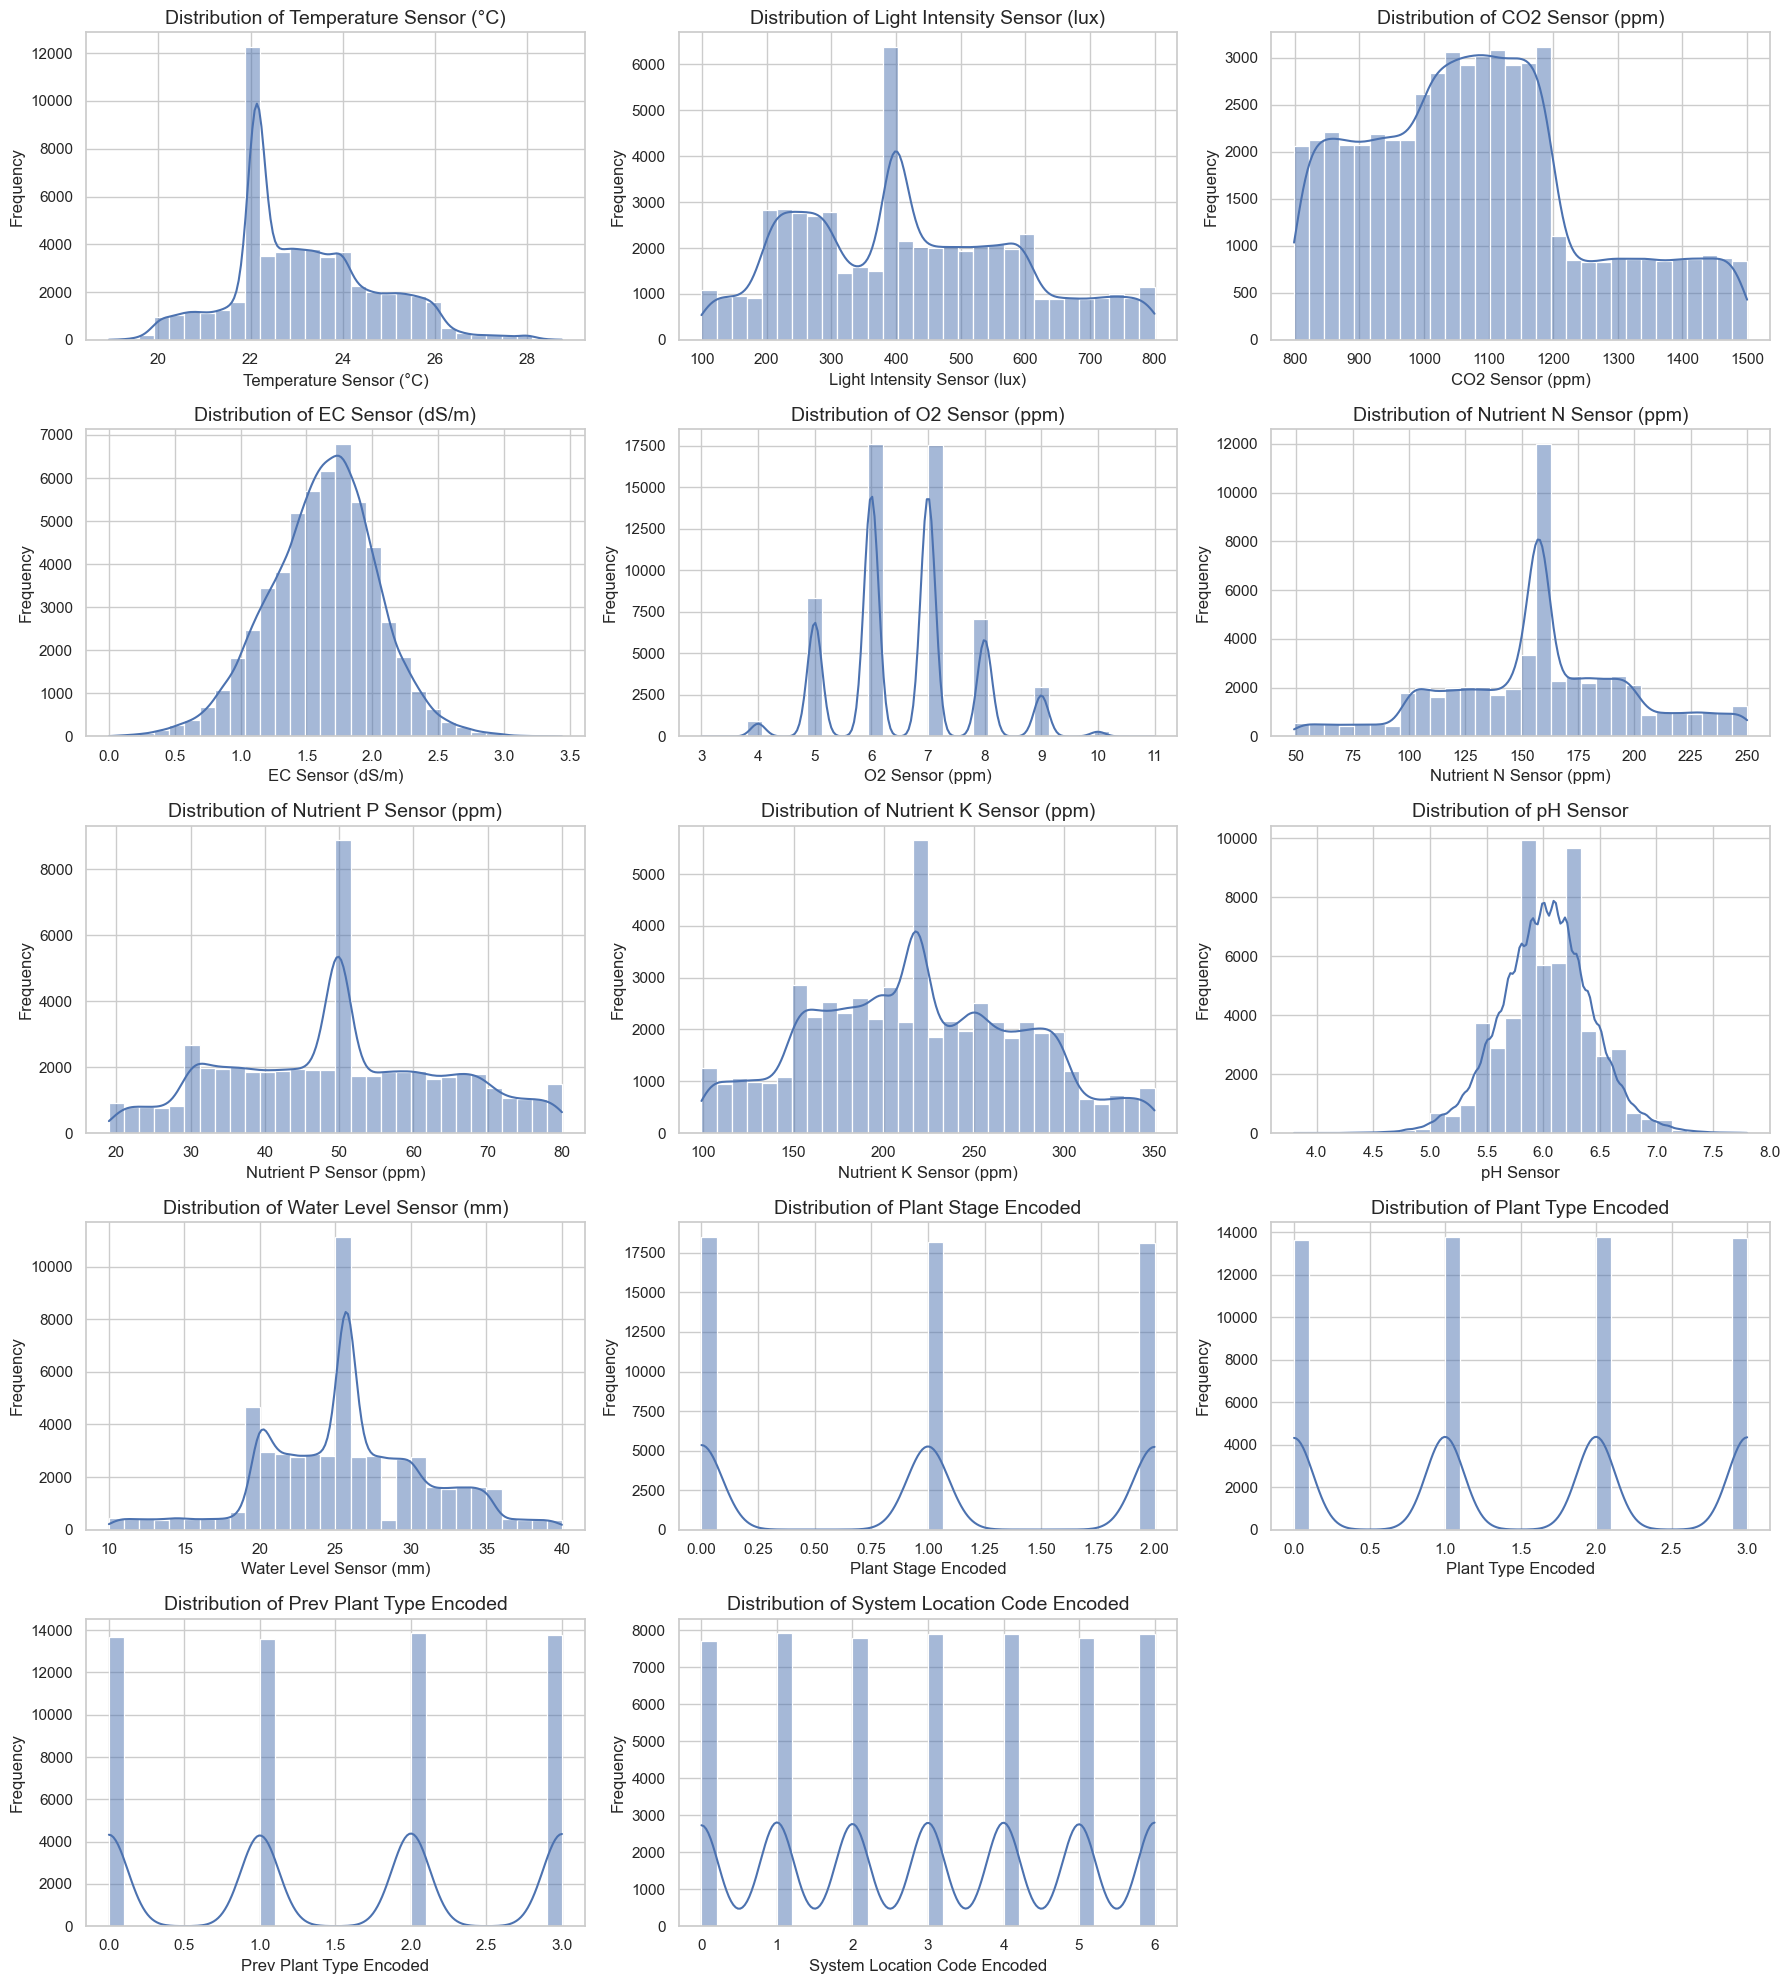

In [22]:
"""
Display distribution of all numeric columns

"""

# Filter numeric columns
numeric_columns = agri_data_cleaned_filtered.select_dtypes(include=['number'])

# Set plot style
sns.set(style="whitegrid")

# Number of columns per row
cols_per_row = 3
num_cols = len(numeric_columns.columns)
num_rows = (num_cols // cols_per_row) + (num_cols % cols_per_row > 0)

# Create subplots
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot each numeric column
for i, column in enumerate(numeric_columns.columns):
    sns.histplot(data=numeric_columns, x=column, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}', fontsize=14)
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()


### **Analysis of Univariate Distribution Charts:**

1. **Temperature, Light Intensity (lux), EC, O2, Nutrient N/P/K, pH, and Water Level Sensor:**
   - These variables show traits of normal distribution with abrupt peaks for one or two x-axis values, except for the EC sensor.
   - **Action:** No transformation is required for these columns, as their distributions align well with normal assumptions.

2. **CO2 Sensor:**
   - The distribution is right-skewed.
   - **Action:** Consider applying a **log transformation** to normalize this variable before incorporating it into predictive models.

3. **Categorical Variables (Plant Type, System Location Code, Previous Cycle Plant Type, Plant Stage):**
   - These variables are **equally distributed** across categories.
   - **Insight:** This balanced distribution will be advantageous for predicting plant stages, as no single category dominates the dataset.

In [27]:
# Select numeric columns except encoded columns
# Assuming encoded columns contain 'Encoded' in their names
numeric_columns = agri_data.select_dtypes(include=['number']).drop(
    columns=[col for col in agri_data.columns if 'Encoded' in col]
)

# Dictionary to store outlier statistics
outlier_stats = {}

# Loop through numeric columns to calculate outliers
for column in numeric_columns.columns:
    q1 = agri_data[column].quantile(0.25)  # 25th percentile
    q3 = agri_data[column].quantile(0.75)  # 75th percentile
    iqr = q3 - q1  # Interquartile range
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = agri_data[(agri_data[column] < lower_bound) | (agri_data[column] > upper_bound)]
    num_outliers = outliers.shape[0]
    percent_outliers = (num_outliers / agri_data.shape[0]) * 100
    
    # Store results in the dictionary
    outlier_stats[column] = {
        "Number of Outliers": num_outliers,
        "Percentage of Outliers": round(percent_outliers, 2)
    }

# Display results
for column, stats in outlier_stats.items():
    print(f"Column: {column}")
    print(f"  Number of Outliers: {stats['Number of Outliers']}")
    print(f"  Percentage of Outliers: {stats['Percentage of Outliers']}%")



Column: Temperature Sensor (°C)
  Number of Outliers: 1575
  Percentage of Outliers: 2.74%
Column: Humidity Sensor (%)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%
Column: Light Intensity Sensor (lux)
  Number of Outliers: 1279
  Percentage of Outliers: 2.22%
Column: CO2 Sensor (ppm)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%
Column: EC Sensor (dS/m)
  Number of Outliers: 870
  Percentage of Outliers: 1.51%
Column: O2 Sensor (ppm)
  Number of Outliers: 4489
  Percentage of Outliers: 7.81%
Column: Nutrient N Sensor (ppm)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%
Column: Nutrient P Sensor (ppm)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%
Column: Nutrient K Sensor (ppm)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%
Column: pH Sensor
  Number of Outliers: 1009
  Percentage of Outliers: 1.76%
Column: Water Level Sensor (mm)
  Number of Outliers: 0
  Percentage of Outliers: 0.0%


### **Outlier Detection Analysis**

1. **Column: Temperature Sensor (°C)**
   - **Outliers:** 2.74%
   - **Recommendation:** 
     - Outliers are relatively low in proportion and can potentially be ignored if they don't significantly affect model performance.
     - However, verify if these outliers are due to faulty sensors or extreme environmental conditions. If they are valid, keep them; otherwise, consider removal or transformation.

2. **Column: Humidity Sensor (%)**
   - **Outliers:** 0%
   - **Recommendation:** No action is needed as there are no outliers.

3. **Column: Light Intensity Sensor (lux)**
   - **Outliers:** 2.22%
   - **Recommendation:** 
     - A low proportion of outliers indicates that you can likely ignore them.
     - However, check if these outliers result from measurement errors or extreme light conditions. If valid, retain them.

4. **Column: CO2 Sensor (ppm)**
   - **Outliers:** 0%
   - **Recommendation:** No action is needed as there are no outliers.

5. **Column: EC Sensor (dS/m)**
   - **Outliers:** 1.51%
   - **Recommendation:** 
     - The proportion of outliers is low and may be ignored unless domain expertise indicates otherwise.
     - If EC values are critical to plant health and these outliers are biologically or operationally unrealistic, consider investigating further.

6. **Column: O2 Sensor (ppm)**
   - **Outliers:** 7.81%
   - **Recommendation:**
     - A relatively higher percentage of outliers.
     - Choose to retain as it is possible that these O2 reading fluctuations are due to environmental conditions and we should not remove from the model but the predictive model built should be robust enough to churn out good results despite some level of outliers.

7. **Column: Nutrient N Sensor (ppm), Nutrient P Sensor (ppm), Nutrient K Sensor (ppm)**
   - **Outliers:** 0%
   - **Recommendation:** No action is needed as there are no outliers.

8. **Column: pH Sensor**
   - **Outliers:** 1.76%
   - **Recommendation:** 
     - The proportion of outliers is low, so you can likely ignore them.

9. **Column: Water Level Sensor (mm)**
   - **Outliers:** 0%
   - **Recommendation:** No action is needed as there are no outliers.

---

### **General Guidelines for Ignoring Outliers**
- **Low Proportion of Outliers (<5%):** You can typically ignore these outliers unless they are critical to the domain or significantly affect the analysis.
- **Context Matters:** Evaluate if the outliers are valid (e.g., extreme environmental conditions) or invalid (e.g., sensor errors or data entry issues).
- **Model Sensitivity:** Some machine learning models, such as tree-based models, are robust to outliers, while others (e.g., linear regression) may be sensitive. Tailor your decision to the modeling approach.

---

### **Next Steps:**

1. **Conduct Multivariate Analysis:**
   - Perform pairwise comparisons between variables to identify potential relationships.
   - **Objective:** Understand how variables interact and influence each other.

2. **Use Pearson's Correlation:**
   - Apply Pearson's correlation to quantify linear relationships between variables.
   - **Focus:** Identify variables with strong correlations to temperature, as temperature prediction is a key project objective.

---

## 3) Multivariate Analysis

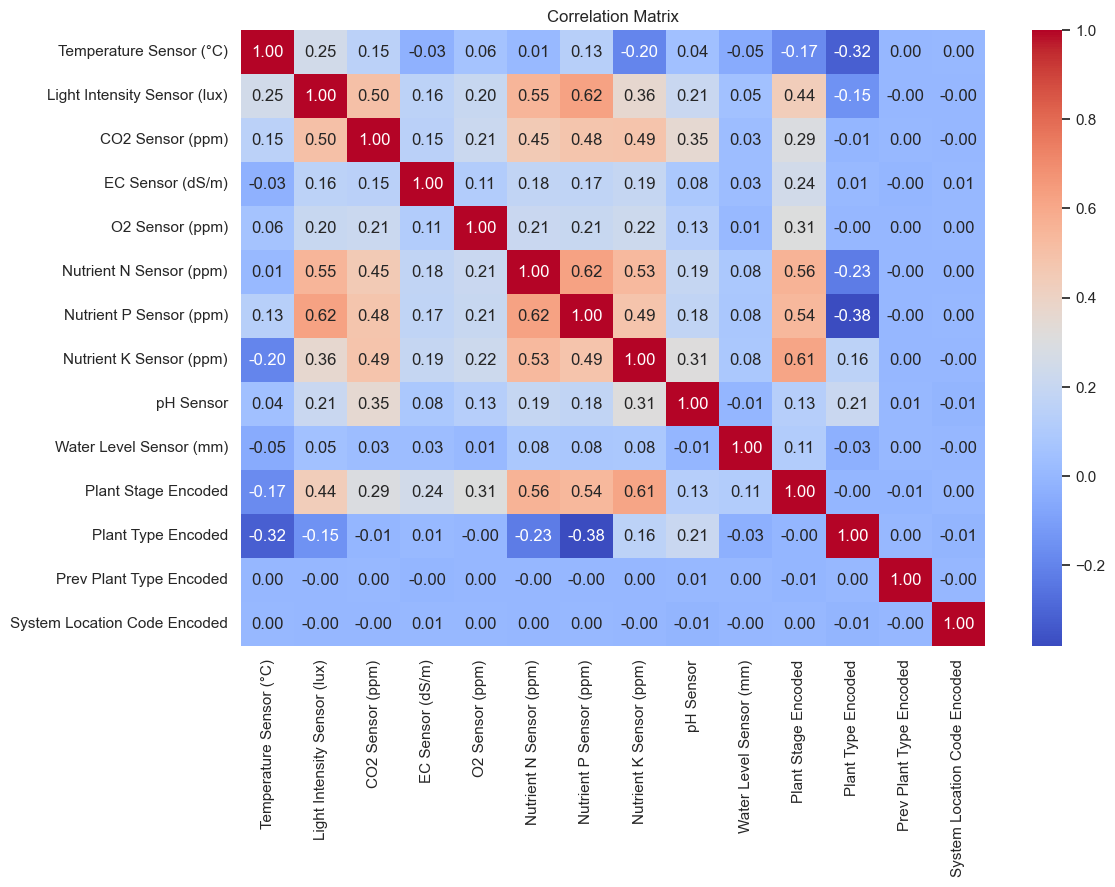

In [24]:
# Compute correlation matrix for numeric columns
numeric_data = agri_data_cleaned_filtered.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### **Findings**

#### **1. Temperature Sensor (°C):**
- **Weak Correlations:** Shows weak correlations with most variables.  
- **Positive Correlation:** Light Intensity Sensor (0.25), indicating a slight relationship between light and temperature.  
- **Negative Correlation:** Plant Type Encoded (-0.32), suggesting that certain plant types may prefer specific temperature ranges.  
- **Next Steps:** Combine variables or create new features to uncover more relationships and rerun the correlation analysis.  

---

#### **2. Light Intensity Sensor (lux):**
- **Strong Positive Correlation:** Nutrient P Sensor (ppm) (0.62), indicating that higher light intensity may be associated with higher phosphorus levels.  
- **Moderate Correlations:**  
  - CO2 Sensor (0.50)  
  - Nutrient N Sensor (0.55), suggesting a potential relationship with light intensity.  
- **Scaling Considerations:** Lux values are quite large (in the thousands) relative to other variables (in the tens).  
- **Next Steps:** Consider log transformation of lux values for correlation studies.  

---

#### **3. CO2 Sensor (ppm):**
- **Moderate Correlations:**  
  - Light Intensity Sensor (0.50)  
  - Nutrient P Sensor (0.48)  
  - Nutrient K Sensor (0.49), indicating CO2 levels may influence or be influenced by nutrient levels and light intensity.  
- **Scaling Considerations:** CO2 values are quite large (in the thousands) relative to other variables (in the tens).  
- **Next Steps:** Consider log transformation of CO2 values for correlation studies.  

---

#### **4. Plant Stage Encoded:**
- **Strong Positive Correlations:**  
  - Nutrient N Sensor (0.56)  
  - Nutrient P Sensor (0.61), suggesting that different growth stages require or are associated with different nutrient levels.  

---

#### **5. pH Sensor:**
- **Weak Correlations:**  
  - Positive correlation with O2 Sensor (0.31).  
  - Slight relationship with Plant Stage Encoded (0.21).  

---

#### **6. Water Level Sensor (mm):**
- **Minimal Correlations:** Shows minimal correlation with other variables, indicating water level may not be strongly related to other sensor readings in this dataset.  

---

## 4. Feature Engineering

In [25]:

# Light and CO2 Combination: Photosynthesis depends on both light intensity and CO2 concentration. Their interaction can directly impact plant growth.
agri_data_cleaned_filtered['Light_per_CO2'] = agri_data_cleaned_filtered['Light Intensity Sensor (lux)'] / agri_data_cleaned_filtered['CO2 Sensor (ppm)']

# Soil Electrical Conductivity (EC) and Nutrients: Electrical conductivity is a proxy for soil salinity and nutrient availability.

agri_data_cleaned_filtered['EC_to_N'] = agri_data_cleaned_filtered['EC Sensor (dS/m)'] / agri_data_cleaned_filtered['Nutrient N Sensor (ppm)']
agri_data_cleaned_filtered['EC_to_P'] = agri_data_cleaned_filtered['EC Sensor (dS/m)'] / agri_data_cleaned_filtered['Nutrient P Sensor (ppm)']
agri_data_cleaned_filtered['EC_to_K'] = agri_data_cleaned_filtered['EC Sensor (dS/m)'] / agri_data_cleaned_filtered['Nutrient K Sensor (ppm)']

# Water Level and Nutrients: Excessive water can leach nutrients, while too little water can reduce nutrient uptake.
agri_data_cleaned_filtered['Total_Nutrients'] = (agri_data_cleaned_filtered['Nutrient N Sensor (ppm)'] +
                                        agri_data_cleaned_filtered['Nutrient P Sensor (ppm)'] +
                                        agri_data_cleaned_filtered['Nutrient K Sensor (ppm)'])

agri_data_cleaned_filtered['Water_to_Nutrients'] = agri_data_cleaned_filtered['Water Level Sensor (mm)'] / agri_data_cleaned_filtered['Total_Nutrients']

# Normalized Nutrients N/P/K using Sum of Nutrients: Normalized features help compare variables with different units.

agri_data_cleaned_filtered['Nutrient_N_Normalized'] = agri_data_cleaned_filtered['Nutrient N Sensor (ppm)'] / agri_data_cleaned_filtered['Total_Nutrients']
agri_data_cleaned_filtered['Nutrient_P_Normalized'] = agri_data_cleaned_filtered['Nutrient P Sensor (ppm)'] / agri_data_cleaned_filtered['Total_Nutrients']
agri_data_cleaned_filtered['Nutrient_K_Normalized'] = agri_data_cleaned_filtered['Nutrient K Sensor (ppm)'] / agri_data_cleaned_filtered['Total_Nutrients']

# Apply log function on light intensity and CO2 readings due to large values.
agri_data_cleaned_filtered['Log_Light_Intensity'] = np.log1p(agri_data_cleaned_filtered['Light Intensity Sensor (lux)'])
agri_data_cleaned_filtered['Log_CO2'] = np.log1p(agri_data_cleaned_filtered['CO2 Sensor (ppm)'])

# Apply log function on light to CO2 readings:
agri_data_cleaned_filtered['Log_Light_per_CO2'] = agri_data_cleaned_filtered['Log_Light_Intensity'] / agri_data_cleaned_filtered['Log_CO2']

C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\1287893545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['Light_per_CO2'] = agri_data_cleaned_filtered['Light Intensity Sensor (lux)'] / agri_data_cleaned_filtered['CO2 Sensor (ppm)']
C:\Users\Razer\AppData\Local\Temp\ipykernel_10428\1287893545.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agri_data_cleaned_filtered['EC_to_N'] = agri_data_cleaned_filtered['EC Sensor (dS/m)'] / agri_data_cleaned_filtered['Nutrient N Sens

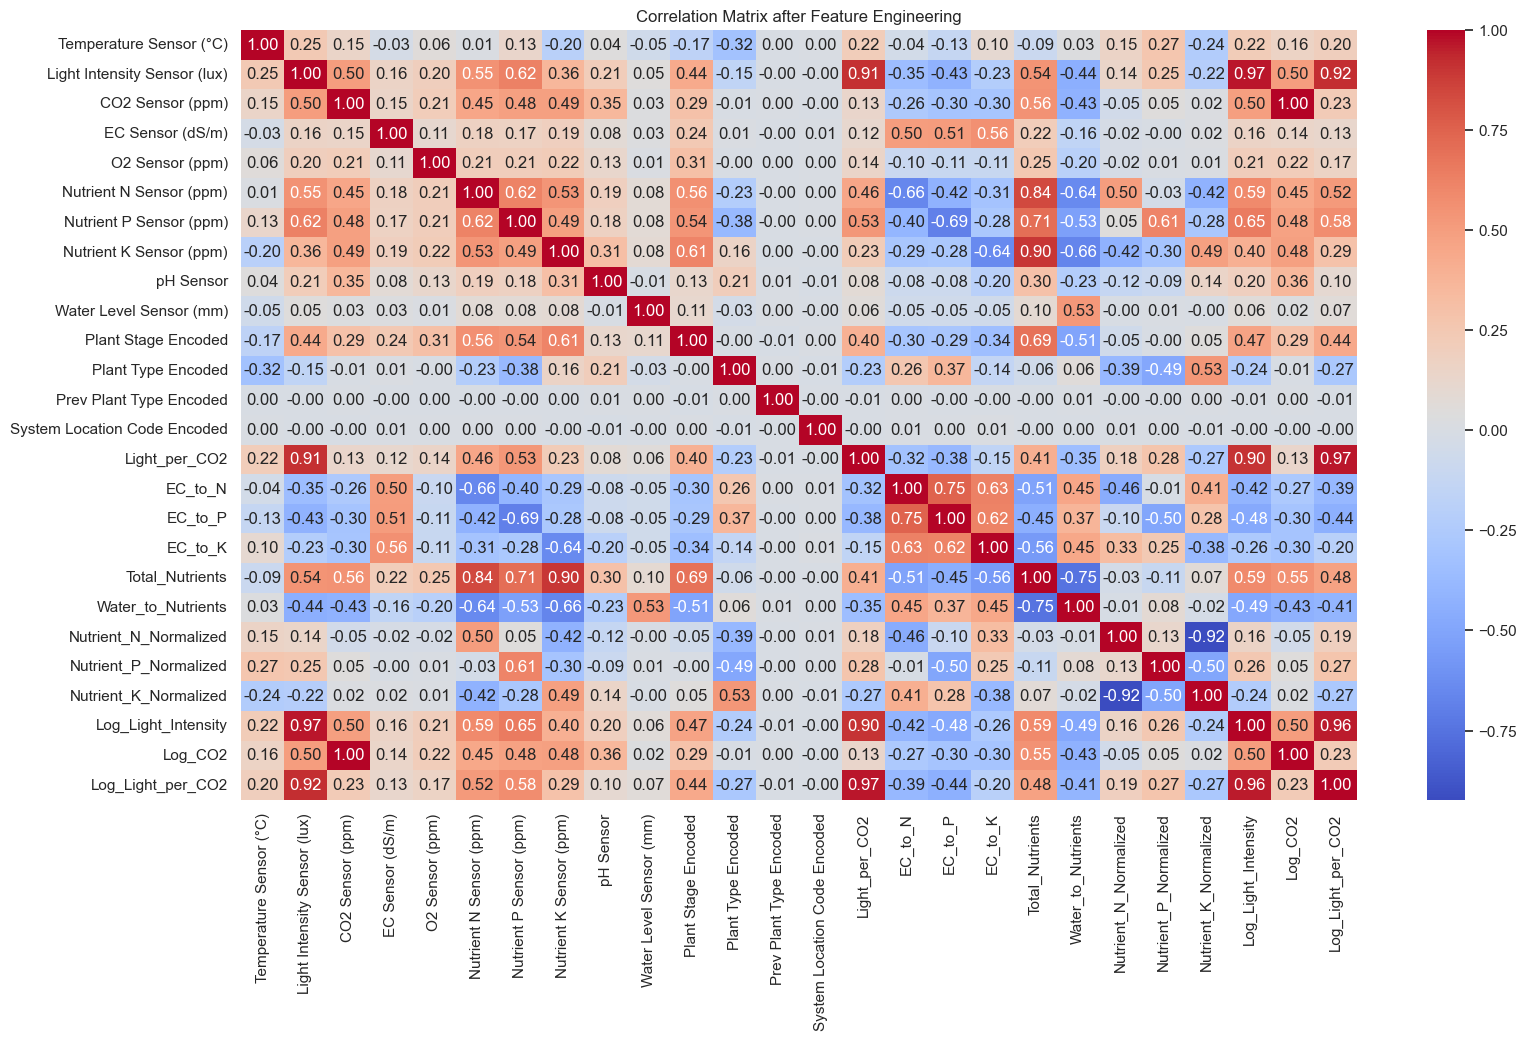

In [28]:
# Compute correlation matrix for numeric columns
numeric_data = agri_data_cleaned_filtered.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix after Feature Engineering')
plt.show()


### **Summary After Feature Engineering**

#### **1. Temperature Sensor (°C):**
- **Improved Correlations:**  
  - **Log_Light_Intensity (0.27):** Log-transformation of light intensity shows a slightly stronger correlation with temperature compared to the original variable (Light Intensity Sensor (lux) at 0.25).  
  - **Light_per_CO2 (0.22):** Interaction between light intensity and CO2 exhibits a positive correlation with temperature, aligning with the energy dynamics in the environment.  
  - **Nutrient_P_Normalized (0.27):** Moderate correlation suggests potential indirect effects of plant demand on nutrient uptake.  

- **Weak Correlations Persist:**  
  - Correlations with most variables remain weak, indicating that temperature in this dataset might depend on external factors or be relatively independent.  

---

#### **2. Plant Stage Encoded:**
- **Strong Correlations:**  
  - **Nutrient_P_Normalized (0.41):** Suggests phosphorus usage varies significantly across different plant growth stages.  
  - **Total_Nutrients (0.61):** Higher nutrient levels correlate strongly with specific plant stages, such as vegetative or maturity stages.  
  - **EC_to_N (-0.46) and EC_to_P (-0.69):** Electrical conductivity negatively correlates with nitrogen and phosphorus availability, possibly due to salinity effects.  

---

### **5. Insights and Recommendations for Predictive Modeling**

#### **Promising Features for Temperature Prediction:**
- **Log_Light_Intensity** and **Light_per_CO2**:  
  - Show improved correlations with temperature after feature engineering.  
  - These features should be prioritized in regression models.  

- **Nutrient_P_Normalized**:  
  - Moderate correlation with temperature (0.27) suggests it could add value as a predictor.  

---

#### **Promising Features for Plant Growth Prediction:**
- **Total_Nutrients** and **Nutrient_P_Normalized**:  
  - Strong correlations with Plant Stage Encoded, making them essential predictors for classification models.  

---

#### **Interaction Features:**
- **Light_per_CO2** and **Water_to_Nutrients**:  
  - Capture logical relationships in agricultural contexts (e.g., photosynthesis and nutrient absorption).  
  - Including these features can improve model explainability and performance.  

---

#### **Exploration of Weak Correlations:**
- Despite feature engineering, the correlation between temperature and other variables remains relatively weak.  
- This indicates that temperature may depend on external factors such as **HVAC systems** or **climate conditions** not captured in the dataset.  

---